In [ ]:
#@title Check if MuJoCo installation was successful

# from google.colab import files

import distutils.util
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
import subprocess
if subprocess.run('nvidia-smi').returncode:
  raise RuntimeError(
      'Cannot communicate with GPU. '
      'Make sure you are using a GPU Colab runtime. '
      'Go to the Runtime menu and select Choose runtime type.')

# Add an ICD config so that glvnd can pick up the Nvidia EGL driver.
# This is usually installed as part of an Nvidia driver package, but the Colab
# kernel doesn't install its driver via APT, and as a result the ICD is missing.
# (https://github.com/NVIDIA/libglvnd/blob/master/src/EGL/icd_enumeration.md)
NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
  with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
    f.write("""{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
""")

# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl

try:
  print('Checking that the installation succeeded:')
  import mujoco
  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".')

print('Installation successful.')

# Tell XLA to use Triton GEMM, this improves steps/sec by ~30% on some GPUs
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags


Thu Mar 19 19:14:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 570.211.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               Off |   00000000:14:00.0 Off |                  Off |
| 30%   37C    P0             65W /  300W |   14227MiB /  49140MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
#@title Import packages for plotting and creating graphics
import time
import itertools
import numpy as np
from typing import Callable, NamedTuple, Optional, Union, List

# Graphics and plotting.
print('Installing mediapy:')
!command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)
!pip install -q mediapy
import mediapy as media
import matplotlib.pyplot as plt

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

Installing mediapy:


In [3]:
#@title Import MuJoCo, MJX, and Brax
from datetime import datetime
from etils import epath
import functools
from IPython.display import HTML
from typing import Any, Dict, Sequence, Tuple, Union
import os
from ml_collections import config_dict


import jax
from jax import numpy as jp
import numpy as np
from flax.training import orbax_utils
from flax import struct
from matplotlib import pyplot as plt
import mediapy as media
from orbax import checkpoint as ocp

import mujoco
from mujoco import mjx

from brax import base
from brax import envs
from brax import math
from brax.base import Base, Motion, Transform
from brax.base import State as PipelineState
from brax.envs.base import Env, PipelineEnv, State
from brax.mjx.base import State as MjxState
from brax.training.agents.ppo import train as ppo
from brax.training.agents.ppo import networks as ppo_networks
from brax.io import html, mjcf, model


Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'


In [21]:
# Path to the robot model
xml_path = "/home/luisamao/villa_spaces/sim_ws/robot_simple_collision.xml"

import os
import mujoco
import xml.etree.ElementTree as ET

# Load and process XML
print(f"Loading model from: {xml_path}")

tree = ET.parse(xml_path)
root = tree.getroot()
# base_dir = os.path.dirname(xml_path)
base_dir = "/home/luisamao/villa_spaces/sim_ws/src/mujoco_cobot/assets"

# 1. Resolve relative include paths
for include_elem in root.findall('include'):
    if 'file' in include_elem.attrib:
        rel_path = include_elem.attrib['file']
        abs_path = os.path.normpath(os.path.join(base_dir, rel_path))
        include_elem.attrib['file'] = abs_path

# 2. FIX: Ensure 'gym_floor_mat' exists
# Find or create the <asset> element
asset_elem = root.find('asset')
if asset_elem is None:
    asset_elem = ET.SubElement(root, 'asset')

# Resolve all mesh and texture paths to absolute paths
for tag in ['mesh', 'texture']:
    for elem in root.findall(f".//{tag}"):
        if 'file' in elem.attrib:
            rel_path = elem.attrib['file']
            # Only change if it's not already an absolute path
            if not os.path.isabs(rel_path):
                abs_path = os.path.normpath(os.path.join(base_dir, rel_path))
                elem.attrib['file'] = abs_path
                # Optional: print for debugging
                # print(f"Resolved {tag}: {rel_path} -> {abs_path}")

# Check if the material is already there; if not, add it
if root.find(".//material[@name='gym_floor_mat']") is None:
    print("Injecting missing 'gym_floor_mat' into assets...")
    # Add a default texture and material so the compiler doesn't crash
    ET.SubElement(asset_elem, 'texture', 
                  type='2d', name='gym_floor_tex', 
                  builtin='checker', rgb1='.2 .3 .4', rgb2='.1 .2 .3', 
                  width='512', height='512')
    ET.SubElement(asset_elem, 'material', 
                  name='gym_floor_mat', 
                  texture='gym_floor_tex', 
                  texrepeat='2 2', specular='0.3', shininess='0.5')

# 3. Convert to string
xml_string = ET.tostring(root, encoding='unicode')

# Compile MuJoCo model
mj_model = mujoco.MjModel.from_xml_string(xml_string)
# make data and renderer
mj_data = mujoco.MjData(mj_model)
renderer = mujoco.Renderer(mj_model)

# model.opt.iterations = 1  # Or 2-4 for more accuracy, but 1 is fastest
# model.opt.ls_iterations = 0 # Disable line search (uses while_loop)
# model.opt.solver = mujoco.mjtSolver.mjSOL_NEWTON
print(f"\nModel loaded successfully!")
print(f"  - DOFs: {mj_model.nv}")
print(f"  - Bodies: {mj_model.nbody}")
print(f"  - Joints: {mj_model.njnt}")
print(f"  - Actuators: {mj_model.nu}")

# Environment configuration
TIMESTEP = 0.002  # 2ms per step
BATCH_SIZE = 4 # 256  # Large batch size for parallel simulations
EPISODE_LENGTH = 20 # 200  # Steps per episode
NUM_EPISODES = 10 # 100  # Total training episodes
LEARNING_RATE = 1e-3

print(f"\nEnvironment Configuration:")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - Episode Length: {EPISODE_LENGTH}")
print(f"  - Total Training Episodes: {NUM_EPISODES}")


Loading model from: /home/luisamao/villa_spaces/sim_ws/robot_simple_collision.xml
Injecting missing 'gym_floor_mat' into assets...

Model loaded successfully!
  - DOFs: 7
  - Bodies: 11
  - Joints: 7
  - Actuators: 7

Environment Configuration:
  - Batch Size: 4
  - Episode Length: 20
  - Total Training Episodes: 10


In [22]:

table_xml_path = "/home/luisamao/villa_spaces/sim_ws/table.xml" # The file we just created
worldbody = root.find('worldbody')

# 2. Inject the include tag into the worldbody
# This is like copy-pasting the table.xml content right here
ET.SubElement(worldbody, 'include', file=table_xml_path)

# --- INJECT BLOCK ON TOP OF TABLE ---
# Table is at [0.8, 0, 0] with top at Z=0.7 and thickness 0.02.
# So table surface is at Z = 0.72.
block_size = [0.03, 0.03, 0.03]
block_pos = [0.8, 0, 0.72 + block_size[2] + 0.5] # Added 5cm air gap to prevent overlap

# 1. Create block body
block_body = ET.SubElement(worldbody, 'body', name='interactive_block', 
                           pos=' '.join(map(str, block_pos)))

# 2. Add freejoint (REQUIRED for moving objects)
ET.SubElement(block_body, 'freejoint', name='block_freejoint')

# 3. Add the geom with the stable physics settings we discussed
ET.SubElement(block_body, 'geom', 
              name='block_geom', 
              type='box', 
              size=' '.join(map(str, block_size)), 
              rgba='0 1 0 1',
              mass='0.1',
              friction='1 0.005 0.0001',
              contype='3',       # Collide with Robot (2) and Environment (1)
              conaffinity='3', 
              solref='0.0005 1.0', # High damping to stop the bounce
              solimp='0.9 0.95 0.001',)

# 3. Resolve paths (as you did before)
# MuJoCo needs absolute paths for included files if they aren't in the same folder
for include_elem in root.findall('.//include'):
    if 'file' in include_elem.attrib:
        rel_path = include_elem.attrib['file']
        if not os.path.isabs(rel_path):
            abs_path = os.path.abspath(rel_path)
            include_elem.attrib['file'] = abs_path

# 4. Convert to string and compile
xml_string = ET.tostring(root, encoding='unicode')
mj_model = mujoco.MjModel.from_xml_string(xml_string)
mj_data = mujoco.MjData(mj_model)

print("Table successfully included from external XML!")

# 3. Convert to string
xml_string = ET.tostring(root, encoding='unicode')

# Compile MuJoCo model
mj_model = mujoco.MjModel.from_xml_string(xml_string)
# make data and renderer
mj_data = mujoco.MjData(mj_model)
renderer = mujoco.Renderer(mj_model)

# model.opt.iterations = 1  # Or 2-4 for more accuracy, but 1 is fastest
# model.opt.ls_iterations = 0 # Disable line search (uses while_loop)
# model.opt.solver = mujoco.mjtSolver.mjSOL_NEWTON
print(f"\nModel loaded successfully!")
print(f"  - DOFs: {mj_model.nv}")
print(f"  - Bodies: {mj_model.nbody}")
print(f"  - Joints: {mj_model.njnt}")
print(f"  - Actuators: {mj_model.nu}")

# Environment configuration
TIMESTEP = 0.002  # 2ms per step
BATCH_SIZE = 4 # 256  # Large batch size for parallel simulations
EPISODE_LENGTH = 20 # 200  # Steps per episode
NUM_EPISODES = 10 # 100  # Total training episodes
LEARNING_RATE = 1e-3

print(f"\nEnvironment Configuration:")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - Episode Length: {EPISODE_LENGTH}")
print(f"  - Total Training Episodes: {NUM_EPISODES}")


Table successfully included from external XML!

Model loaded successfully!
  - DOFs: 13
  - Bodies: 13
  - Joints: 8
  - Actuators: 7

Environment Configuration:
  - Batch Size: 4
  - Episode Length: 20
  - Total Training Episodes: 10


In [24]:
# enable joint visualization option:
mj_model.opt.solver = mujoco.mjtSolver.mjSOL_NEWTON
mj_model.opt.iterations = 30     # Increase from 6
mj_model.opt.ls_iterations = 10  # Important for Newton stability

scene_option = mujoco.MjvOption()
scene_option.flags[mujoco.mjtVisFlag.mjVIS_JOINT] = True

duration = 3.8  # (seconds)
framerate = 60  # (Hz)

frames = []
mujoco.mj_resetData(mj_model, mj_data)
while mj_data.time < duration:
  mujoco.mj_step(mj_model, mj_data)
  if len(frames) < mj_data.time * framerate:
    renderer.update_scene(mj_data, scene_option=scene_option, camera="sideview")
    pixels = renderer.render()
    frames.append(pixels)

# Simulate and display video.
media.show_video(frames, fps=framerate)

In [ ]:
import functools
import jax
import jax.numpy as jp
from datetime import datetime
from brax import envs
from brax.envs.base import Env, PipelineEnv, State  # The fix for Brax 0.14.1
from brax.training.agents.ppo import train as ppo
import mujoco

from brax.io import mjcf

class CobotEnv(PipelineEnv):
    def __init__(self, **kwargs):
        # 1. Load your MuJoCo model into the Brax system
        # 'mj_model' is your mujoco.MjModel object from the previous cell
        mj_model.opt.solver = mujoco.mjtSolver.mjSOL_NEWTON
        mj_model.opt.iterations = 30     # Increase from 6
        mj_model.opt.ls_iterations = 10  # Important for Newton stability
        sys = mjcf.load_model(mj_model)
        # sys = mjx.put_model(mjx_model)
        
        # 2. Physics steps per control step (usually 4-5)
        n_frames = 5
        
        # 3. Initialize the PipelineEnv with the MJX backend
        super().__init__(sys, n_frames=n_frames, backend='mjx', **kwargs)
        
        # Define target position
        # self.target_pos = jp.array([0.3, 0.5, 0.5])
        self._ee_site_idx = mujoco.mj_name2id(
            sys.mj_model, mujoco.mjtObj.mjOBJ_SITE, 'pinch_site'
        )
        print(f"Number of mocap bodies: {sys.mj_model.nmocap}")
        
    def reset(self, rng: jp.ndarray) -> State:
        # qpos0 exists and is the 'home' position from your XML
        # qpos = self.sys.mj_model.qpos0
        # qpos = jp.array([-0.979, 1.019, 0.144, 1.003, -0.221, 0.986, -0.886])
        # qpos = jp.array([0, 1.019, 0.144, 1.003, -0.221, 0.986, -0.886])
        qpos = jp.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
        
        # qvel0 does NOT exist in MjModel; create a zero array for velocity instead
        # self.sys.nv is the number of velocity degrees of freedom
        qvel = jp.zeros(self.sys.nv)
        
        # Initialize the physics pipeline
        data = self.pipeline_init(qpos, qvel)
        
        obs = self._get_obs(data)
        reward, done = jp.zeros(2)
        metrics = {'dist': jp.zeros(()), 'floor_penalty': jp.zeros(())}

                # 1. Split the RNG key for different random operations
        rng, target_key = jax.random.split(rng)
        
        # 2. Define the target workspace bounds [min, max]
        # Adjust these values so the target stays within the robot's reach
        low = jp.array([0.2, -0.5, 0.3])
        high = jp.array([0.8, 0.5, 1.0])
        
        # 3. Generate the random target position
        target_pos = jax.random.uniform(target_key, (3,), minval=low, maxval=high)
        
        # Initialize physics
        pipeline_state = self.pipeline_init(qpos, qvel)

        new_mocap_pos = pipeline_state.mocap_pos.at[0].set(target_pos)
        pipeline_state = pipeline_state.replace(mocap_pos=new_mocap_pos)

        info = {
            'prev_action': jp.zeros(self.action_size),
            'target_pos': target_pos  # Store target in info to access it in step()
        }
                
        return State(data, obs, reward, done, metrics, info)
    
    # let ctrl be the 7-dim vector input in sim. let action be 11 dim output from policy
    def ctrl_to_action(self, ctrl_7: jp.ndarray) -> jp.ndarray:
        # Physical limits for the bounded joints (indices 1, 3, 5)
        low_lim = jp.array([-2.24, -2.57, -2.09])
        high_lim = jp.array([2.24, 2.57, 2.09])
        
        # 1. Infinite Joints: Map [-1, 1] to [-pi, pi] then to sin/cos
        # Indices 0, 2, 4, 6
        inf_angles = ctrl_7[jp.array([0, 2, 4, 6])]
        sins = jp.sin(inf_angles)
        coss = jp.cos(inf_angles)
        
        # 2. Limited Joints: Scale [-1, 1] to [low, high] radians
        # Indices 1, 3, 5
        lim_actions = ctrl_7[jp.array([1, 3, 5])]
        lim_norm = 2.0 * (lim_actions - low_lim) / (high_lim - low_lim) - 1.0
        
        # 3. Assemble 11-dim Control Vector
        ctrl_11 = jp.array([
            sins[0], coss[0], # J0 (Inf)
            lim_norm[0],    # J1 (Lim)
            sins[1], coss[1], # J2 (Inf)
            lim_norm[1],    # J3 (Lim)
            sins[2], coss[2], # J4 (Inf)
            lim_norm[2],    # J5 (Lim)
            sins[3], coss[3]  # J6 (Inf)
        ])
        return ctrl_11 

    def action_to_ctrl(self, action_11: jp.ndarray) -> jp.ndarray:
        """Converts 11-dim (sin/cos/lim) back to 7-dim radians."""
        # 1. Convert sin/cos pairs back to radians using atan2
        # atan2(sin, cos) returns the angle in [-pi, pi]
        rad_0 = jp.atan2(action_11[0], action_11[1])
        rad_2 = jp.atan2(action_11[3], action_11[4])
        rad_4 = jp.atan2(action_11[6], action_11[7])
        rad_6 = jp.atan2(action_11[9], action_11[10])
        
        # 2. Limited joints are already in radians (from the action_to_ctrl scaling)
        low_lim = jp.array([-2.24, -2.57, -2.09])
        high_lim = jp.array([2.24, 2.57, 2.09])
        rad_1 = action_11[2]
        rad_3 = action_11[5]
        rad_5 = action_11[8]
        # scale from [-1, 1] to limits
        rad_1 = low_lim[0] + (high_lim[0] - low_lim[0]) * (rad_1 + 1) / 2
        rad_3 = low_lim[1] + (high_lim[1] - low_lim[1]) * (rad_3 + 1) / 2
        rad_5 = low_lim[2] + (high_lim[2] - low_lim[2]) * (rad_5 + 1) / 2

        return jp.array([rad_0, rad_1, rad_2, rad_3, rad_4, rad_5, rad_6])
    
    def step(self, state: State, action: jp.ndarray) -> State:
        # jax.debug.print("Received action: {a}", a=action)
        curr_pose = state.pipeline_state.qpos
        scaled_action = self.action_to_ctrl(action)
        # jax.debug.print("Scaled action (ctrl): {a}", a=scaled_action)

        # Step the physics
        data = self.pipeline_step(state.pipeline_state, scaled_action)
        target_pos = state.info['target_pos']
        new_mocap_pos = data.mocap_pos.at[0].set(target_pos)
        data = data.replace(mocap_pos=new_mocap_pos)
        
        # --- REWARD & PENALTIES ---
        # 1. Distance Reward (Reach)
        # Using data.xpos[1] as a placeholder for your hand/end-effector
        hand_pos = data.site_xpos[self._ee_site_idx]
        # jax.debug.print("Hand Position: {x}", x=hand_pos)
        dist = jp.linalg.norm(hand_pos - target_pos)
        reward_reach = -dist

        # action_delta = scaled_action - curr_pose
        # action_rate_cost = 0.05 * jp.sum(jp.square(action_delta))
        action_rate_cost = 0.0
        
        # 2. Control Penalty (Action regularization)
        # ctrl_cost = 0.01 * jp.sum(jp.square(action))
        ctrl_cost = 0.0
        
        # 3. Floor Penalty (Collision Avoidance)
        # If the hand goes below 0.05m, apply a heavy penalty
        # floor_penalty = jp.where(hand_pos[2] < 0.05, 50.0, 0.0)
        floor_penalty = 0.0
        
        reward = reward_reach - ctrl_cost - floor_penalty - action_rate_cost
        
        # Logic for 'done' (optional: terminate if too far away)
        # done = jp.where(dist > 1.5, 1.0, 0.0)
        done = jp.zeros_like(dist)
        
        obs = self._get_obs(data)
        
        # Update metrics for tracking in the plot
        state.metrics.update(dist=dist, floor_penalty=floor_penalty)
        
        return state.replace(pipeline_state=data, obs=obs, reward=reward, done=done)

    def _get_obs(self, data: mjx.Data) -> jp.ndarray:
        # Standard observation: joint positions and velocities
        # rel_pos = data.site_xpos[self._ee_site_idx] - self.target_pos
        target_pos = data.mocap_pos[0]  # Target position from mocap
        return jp.concatenate([data.qpos, data.qvel, target_pos]) # or give ee pos

# Register the environment
envs.register_environment('cobot_reach', CobotEnv)


In [20]:
env_name = "cobot_reach"
env = envs.get_environment(env_name)

# define the jit reset/step functions
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)

# initialize the state
state = jit_reset(jax.random.PRNGKey(0))
rollout = [state.pipeline_state]
og_pose = state.pipeline_state.q

# grab a trajectory
for i in range(500):
  ctrl = og_pose # [-0, 1.019, 0.144, 1.003, -0.221, 0.986, -0.886]
  ctrl = ctrl.at[0].set(min(i/300, 1.0)*3.14)
  ctrl = env.ctrl_to_action(ctrl)
  state = jit_step(state, ctrl)
  print("target pos:", state.pipeline_state.mocap_pos[0])
  print("ctrl:", ctrl)
  print("state:", state.pipeline_state.q)
  breakpoint()
  rollout.append(state.pipeline_state)

media.show_video(env.render(rollout, camera = "sideview"), fps=1.0 / env.dt)

/scratch/luisamao/conda/envs/cobot/lib/python3.10/site-packages/brax/io/mjcf.py:480: UserWarning: Brax System, piplines and environments are not actively being maintained. Please see MJX for a well maintained JAX-based physics engine: https://github.com/google-deepmind/mujoco/tree/main/mjx. For a host of environments that use MJX, see: https://github.com/google-deepmind/mujoco_playground.
  warnings.warn(


Number of mocap bodies: 1
target pos: [0.3 0.5 0.5]
ctrl: [0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1.]
state: [ 0.  0.  0. -0. -0. -0. -0.]
target pos: [0.3 0.5 0.5]
ctrl: [0.01 1.   0.   0.   1.   0.   0.   1.   0.   0.   1.  ]
state: [ 0.002  0.    -0.     0.    -0.    -0.    -0.   ]
target pos: [0.3 0.5 0.5]
ctrl: [0.021 1.    0.    0.    1.    0.    0.    1.    0.    0.    1.   ]
state: [ 0.005  0.    -0.     0.    -0.     0.    -0.   ]
target pos: [0.3 0.5 0.5]
ctrl: [0.031 1.    0.    0.    1.    0.    0.    1.    0.    0.    1.   ]
state: [ 0.01  0.   -0.    0.   -0.    0.   -0.  ]
target pos: [0.3 0.5 0.5]
ctrl: [0.042 0.999 0.    0.    1.    0.    0.    1.    0.    0.    1.   ]
state: [ 0.016  0.    -0.     0.    -0.     0.    -0.   ]
target pos: [0.3 0.5 0.5]
ctrl: [0.052 0.999 0.    0.    1.    0.    0.    1.    0.    0.    1.   ]
state: [ 0.023  0.    -0.     0.    -0.     0.    -0.   ]
target pos: [0.3 0.5 0.5]
ctrl: [0.063 0.998 0.    0.    1.    0.    0.    1.    0.    0.    1.   

This browser does not support the video tag.


In [9]:
# List names of all cameras in the model
for i in range(mj_model.ncam):
    print(f"Camera ID: {i}, Name: {mujoco.mj_id2name(mj_model, mujoco.mjtObj.mjOBJ_CAMERA, i)}")

media.show_video(env.render(rollout), fps=1.0 / env.dt)

In [ ]:
train_fn = functools.partial(
    ppo.train,
    num_timesteps=40_000_000, # Increased for better learning
    num_evals=10,
    reward_scaling=1/100,
    episode_length=1000,      # Increased so it has time to reach
    normalize_observations=True,
    entropy_cost = 1e-2,
    action_repeat=1,
    unroll_length=10,
    num_minibatches=24,
    num_updates_per_batch=8,
    discounting=0.99,
    learning_rate=3e-4,
    num_envs=2048,
    batch_size=512,
    seed=42
)

def progress_callback(num_steps, metrics):
    now = datetime.now().strftime('%H:%M:%S')
    
    # Use .get(key, default) to prevent KeyErrors
    reward = metrics.get('eval/episode_reward', 0.0)
    loss = metrics.get('training/total_loss', 0.0)
    sps = metrics.get('training/sps', 0.0)
    
    print(f"[{now}] Steps: {num_steps:>10} | Reward: {reward:>10.2f} | Loss: {loss:>10.4f} | SPS: {sps:>8.0f}")

print(f"[{datetime.now().strftime('%H:%M:%S')}] Starting Training...")
make_inference_fn, params, metrics = train_fn(environment=envs.get_environment('cobot_reach'), progress_fn=progress_callback)
print(f"[{datetime.now().strftime('%H:%M:%S')}] Training Complete!")

In [27]:
model_path = 'mjx_brax_policy'
# model.save_params(model_path, params)

params = model.load_params(model_path)
make_inference_fn, _, metrics = train_fn(environment=envs.get_environment('cobot_reach'), num_timesteps=0) # dummy train to get the make_inference_fn
inference_fn = make_inference_fn(params)

/scratch/luisamao/conda/envs/cobot/lib/python3.10/site-packages/brax/io/mjcf.py:480: UserWarning: Brax System, piplines and environments are not actively being maintained. Please see MJX for a well maintained JAX-based physics engine: https://github.com/google-deepmind/mujoco/tree/main/mjx. For a host of environments that use MJX, see: https://github.com/google-deepmind/mujoco_playground.
  warnings.warn(


Number of mocap bodies: 1


AttributeError: 'CobotEnv' object has no attribute '_fixed_target'

In [10]:
# examine the trained policy
env_name = "cobot_reach"
env = envs.get_environment(env_name)
inference_fn = jax.jit(make_inference_fn(params))
jit_inference_fn = jax.jit(inference_fn)
eval_env = envs.get_environment(env_name)

jit_reset = jax.jit(eval_env.reset)
jit_step = jax.jit(eval_env.step)

# initialize the state
rng = jax.random.PRNGKey(0)
state = jit_reset(rng)
rollout = [state.pipeline_state]

# grab a trajectory
n_steps = 500
render_every = 2

for i in range(n_steps):
  act_rng, rng = jax.random.split(rng)
  ctrl, _ = jit_inference_fn(state.obs, act_rng)
  state = jit_step(state, ctrl)
  rollout.append(state.pipeline_state)

  # print the reward
  print(f"Step {i+1}/{n_steps} | Reward: {state.reward:.3f} | Distance: {state.metrics['dist']:.3f}")

  if state.done:
    print("Done", len(rollout), n_steps)
    break

media.show_video(env.render(rollout[::render_every], camera="sideview"), fps=1.0 / env.dt / render_every)

Number of mocap bodies: 1
Number of mocap bodies: 1
Step 1/500 | Reward: -1.251 | Distance: 1.251
Step 2/500 | Reward: -1.248 | Distance: 1.248
Step 3/500 | Reward: -1.243 | Distance: 1.243
Step 4/500 | Reward: -1.233 | Distance: 1.233
Step 5/500 | Reward: -1.212 | Distance: 1.212
Step 6/500 | Reward: -1.181 | Distance: 1.181
Step 7/500 | Reward: -1.140 | Distance: 1.140
Step 8/500 | Reward: -1.093 | Distance: 1.093
Step 9/500 | Reward: -1.034 | Distance: 1.034
Step 10/500 | Reward: -0.961 | Distance: 0.961
Step 11/500 | Reward: -0.880 | Distance: 0.880
Step 12/500 | Reward: -0.802 | Distance: 0.802
Step 13/500 | Reward: -0.730 | Distance: 0.730
Step 14/500 | Reward: -0.668 | Distance: 0.668
Step 15/500 | Reward: -0.612 | Distance: 0.612
Step 16/500 | Reward: -0.564 | Distance: 0.564
Step 17/500 | Reward: -0.525 | Distance: 0.525
Step 18/500 | Reward: -0.493 | Distance: 0.493
Step 19/500 | Reward: -0.468 | Distance: 0.468
Step 20/500 | Reward: -0.446 | Distance: 0.446
Step 21/500 | Rew

This browser does not support the video tag.


In [1]:
media.show_video(env.render(rollout[::render_every], camera="topdown"), fps=1.0 / env.dt / render_every)

NameError: name 'media' is not defined

In [15]:
# print the last control and the joint positions
print("Final Control:", ctrl)
print("Final Joint Positions:", state.pipeline_state.q)

Final Control: [-0.999  1.     0.382  1.     0.039  0.993 -0.777]
Final Joint Positions: [-1.001  1.02  -0.061  1.005  0.027  0.995 -0.737]


In [61]:
# media.show_video(env.render(rollout[::render_every]), fps=1.0 / env.dt / render_every)
print(len(rollout))

501


In [81]:
# Compare current joint positions to the model limits
qpos = state.pipeline_state.q
low, high = env.sys.mj_model.jnt_range.T

for i in range(env.sys.nq):
    print(f"Joint {i}: {qpos[i]:.3f} | Limits: [{low[i]:.3f}, {high[i]:.3f}]")

Joint 0: -0.997 | Limits: [-inf, inf]
Joint 1: 1.020 | Limits: [-2.240, 2.240]
Joint 2: -0.096 | Limits: [-inf, inf]
Joint 3: 1.003 | Limits: [-2.570, 2.570]
Joint 4: 0.166 | Limits: [-inf, inf]
Joint 5: 0.992 | Limits: [-2.090, 2.090]
Joint 6: 0.153 | Limits: [-inf, inf]


After strong control input:
Reward: -0.194 | Distance: 0.194


""

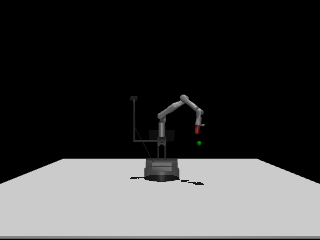

In [ ]:
# Instead of -0.1, try a stronger push toward the target
# the model is clipping the ctrl to -1,1 but this is interpreted by radians by the joint control...
ctrl = jp.array([-1.2,  1.,     0.382,  1.4,     0.039,  0.993, -0.777])
state = jit_step(state, ctrl)
print("After strong control input:")
print(f"Reward: {state.reward:.3f} | Distance: {state.metrics['dist']:.3f}")

single_frame_rollout = [state.pipeline_state]

# 3. Render and display
# We use media.show_image because it's a single frame
image = env.render(single_frame_rollout, camera="sideview")[0]
media.show_image(image)